In [5]:
import openmc
import os
import numpy as np
from Geometry_methods import set_geom_fuel_shell, make_settings, set_mat

In [11]:
fuel_ir = 115
fuel_or = 120
water_or = 180

with_blanket = True
blanket_or = 200 

inner_moderator_height = 160

geom,_= set_geom_fuel_shell(fuel_ir,fuel_or,water_or,with_blanket,blanket_or,inner_moderator_height)
#print(cells)
fuel = geom.get_cells_by_name('fuel')[0]
moderator = geom.get_cells_by_name('moderator')[0]
blanket = geom.get_cells_by_name('blanket')[0]
air_cell = geom.get_cells_by_name('air')[0]


Fuel CA_1
Fuel CA_2
Blanket CA
Fuel A
Fuel B
Fuel C
Air
h2o
d2o
uo2


<Axes: xlabel='x [cm]', ylabel='y [cm]'>

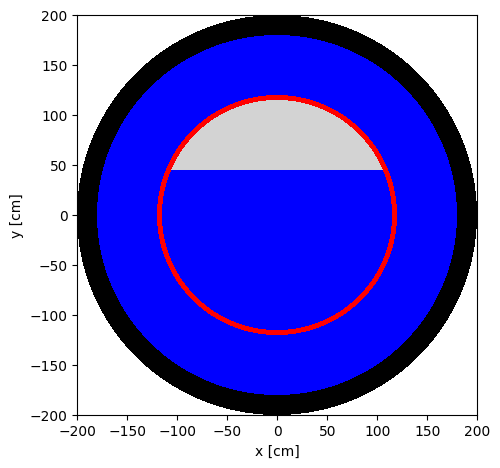

In [12]:
cell_colors = {
    fuel: 'red',
    moderator: 'blue',
    air_cell: "lightgrey",
    blanket: 'black'
    }


geom.plot(
    pixels=(400, 400),       # resolution
    basis='xy',              # plane (xy, xz, yz)
    color_by='cell',     # color by material or cell
    colors = cell_colors
    )

In [13]:
def stochastic_vol_calc(fuel_cell,geom_or):
    settings_vol = openmc.Settings()
    
    geom = openmc.Geometry.from_xml("geometry.xml")
    mat = openmc.Materials.from_xml("materials.xml")
    vol_model = openmc.Model(geometry=geom, materials=mat, settings=settings_vol)
    
    lower_left = (-geom_or,-geom_or,-geom_or)
    upper_right = (geom_or,geom_or,geom_or)
    fuel_vol_calc = openmc.VolumeCalculation([fuel_cell],int(1e7),lower_left, upper_right) #max # of points 1e8 before slow calc
    
    #Trigger to stop vol_calc if it is precise enough before number of sambling points 
    #makes calculation slow for some reason
    fuel_vol_calc.set_trigger(1e-3, 'rel_err')  
    settings.run_mode = 'volume'
    settings_vol.volume_calculations = [fuel_vol_calc]
    
    vol_model.calculate_volumes()
def shell_vol_calc(outer_radius,inner_radius):
    volume=4/3*np.pi*(outer_radius**3-inner_radius**3)
    return volume

In [16]:
print("Blanket volume\t",shell_vol_calc(100,87))
print("Moderator volume (full)",shell_vol_calc(47,0)+shell_vol_calc(87,50))
print("Fuel volume\t",shell_vol_calc(50,47))

Blanket volume	 1430459.288563938
Moderator volume (full) 2669624.906055691
Fuel volume	 88706.01016676139
